In [9]:
import numpy as np
import matplotlib.pyplot as plt

from b_modes_modules.cosmology_spec import CosmologySpec
from b_modes_modules.cls_spec import ClSpec, Tracer, Mask
from b_modes_modules.calc_cls import calc_cl
from b_modes_modules.theoretical_lps import get_kappa_power

In [23]:
# define survey specs

tracer_no_IA = Tracer(bin_num=tuple(range(6)), lens_order=2, IA="off")

cls_spec_no_IA = ClSpec(
    nside=512,
    tracer_1=tracer_no_IA,
    tracer_2=tracer_no_IA,
    nlb=16
)

tracer = Tracer(bin_num=tuple(range(6)), lens_order=2, IA="real")

cls_spec = ClSpec(
    nside=512,
    tracer_1=tracer,
    tracer_2=tracer,
    nlb=16
)

tracer_no_lens = Tracer(bin_num=tuple(range(6)), lens_order=0, IA="real")

cls_spec_no_lens = ClSpec(
    nside=512,
    tracer_1=tracer_no_lens,
    tracer_2=tracer_no_lens,
    nlb=16
)

In [24]:
# calc cl

export_data_no_IA = calc_cl(cls_spec_no_IA)
export_data = calc_cl(cls_spec)
export_data_no_lens = calc_cl(cls_spec_no_lens)

In [25]:
# calc theory cl

ls_th, ee_th = get_kappa_power(cls_spec_no_IA)

/Users/Frugt001/Desktop/galaxy_b_modes/b_modes_modules/theoretical_lps.py:72: RuntimeWarning: invalid value encountered in divide
  l_conversion = 2 * np.sqrt((L-1) * L * (L+1) * (L+2)) / (L * (L + 1))


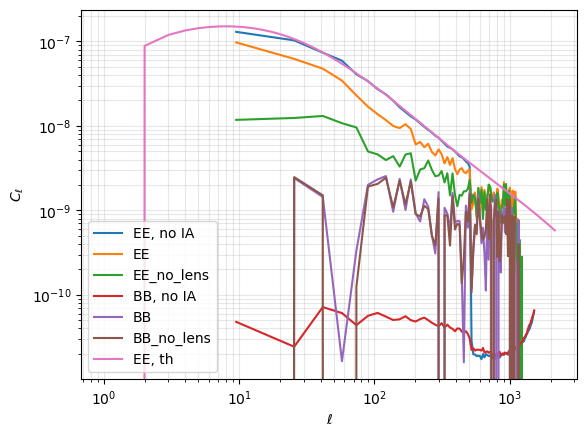

In [26]:
ee_no_IA, eb_no_IA, be_no_IA, bb_no_IA, ells_no_IA = export_data_no_IA
ee, eb, be, bb, ells = export_data
ee_no_lens, eb_no_lens, be_no_lens, bb_no_lens, ells_no_lens = export_data_no_lens

plt.loglog(ells_no_IA, ee_no_IA, label="EE, no IA")
plt.loglog(ells, ee, label="EE")
plt.loglog(ells_no_lens, ee_no_lens, label="EE_no_lens")
plt.loglog(ells_no_IA, bb_no_IA, label="BB, no IA")
plt.loglog(ells, bb, label="BB")
plt.loglog(ells_no_lens, bb_no_lens, label="BB_no_lens")

plt.loglog(ls_th, ee_th, label="EE, th")

plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()

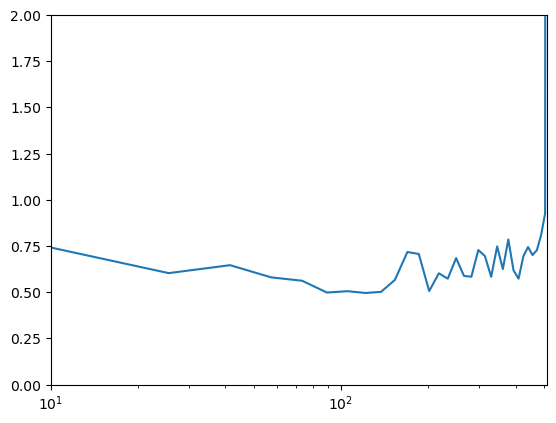

In [ ]:
plt.semilogx(ells_no_IA, ee / ee_no_IA)
plt.xlim(10, 512)
plt.ylim(0, 2)
plt.show()

In [ ]:

# if __name__ == "__main__":
#     mask_dirs = {
#         "none": config.CLS_UNMASKED,
#         "special": config.CLS_MASKED_SPECIAL,
#         "random": config.CLS_MASKED_RANDOM,
#     }
#     for d in mask_dirs.values():
#         d.mkdir(parents=True, exist_ok=True)

#     tracers = [Tracer(bin_num=i, field_type="shape", lens_order=2, scramble="none") for i in range(config.NUM_Z_BINS)]

#     for mask_kind in ["none", "special", "random"]:
#         mask = Mask(kind=mask_kind)
#         for t1, t2 in itertools.combinations_with_replacement(tracers, 2):
#             print(f"bin {t1.bin_num}x{t2.bin_num}, mask {mask_kind}")
#             dataset1, dataset2 = select_dataset(t1, t2, mask=mask)
#             calc_cl(config.CL_BIN_PAIR_NAME(t1.bin_num, t2.bin_num), dataset1, dataset2, out_dir=mask_dirs[mask_kind])